# QQ音乐歌曲数据分析

## 结论摘要

1. 2053首有效歌曲的平均歌词重复率为38.48%，81.25%的歌曲位于20%至60%；歌词重复率与评论平均长度几乎无线性关系（相关系数为-0.016）。
2. 同歌手歌曲的平均TF-IDF余弦相似度为0.0876，约为不同歌手0.0238的3.68倍。
3. 在本次样本中，从1960年代至2000年代出生歌手的歌词平均重复率呈连续下降趋势。


## 一、背景与方法

### 研究问题

- 歌词重复率具有怎样的分布，是否能够解释评论篇幅？
- 同一歌手不同歌曲的歌词用词是否更相似？
- 不同出生年代歌手的歌词重复率是否存在差异？

### 关键假设

- 重复率只识别内容完全相同的歌词行（直接用“set”集合进行判断），不识别语义重复。
- 每首歌曲只采集约3条评论，因此评论长度只代表当前评论样本。
- 相似度和出生年代分析排除合唱歌曲，只保留具有唯一歌手ID的独唱歌曲。


## 二、运行环境与数据

本次分析使用 `json`、`re`、`jieba`、`NumPy`、`Matplotlib` 和 `scikit-learn`。可在终端运行：

```powershell
python -m pip install jieba numpy matplotlib scikit-learn
```


In [3]:
%matplotlib inline

import json
import random
import re
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import jieba
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR if (CURRENT_DIR / "music_site").exists() else CURRENT_DIR.parent
SONGS_PATH = PROJECT_ROOT / "music_site" / "data" / "songs.json"
SINGERS_PATH = PROJECT_ROOT / "music_site" / "data" / "singers.json"
OUTPUT_DIR = PROJECT_ROOT / "data_analysis" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

print("项目根目录：", PROJECT_ROOT)
print("图表输出目录：", OUTPUT_DIR)

项目根目录： C:\Users\13811\Desktop\python_summer_project1
图表输出目录： C:\Users\13811\Desktop\python_summer_project1\data_analysis\output


In [4]:
def load_json(path):
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


songs = load_json(SONGS_PATH)
singers = load_json(SINGERS_PATH)

comment_count = sum(len(song.get("song_comments", [])) for song in songs)

print(f"歌曲数量：{len(songs)}")
print(f"歌手数量：{len(singers)}")
print(f"评论数量：{comment_count}")

歌曲数量：2060
歌手数量：250
评论数量：6156


## 三、数据清洗
数据清洗的条例如下： 
```text 
一、清洗制作信息  
  原始歌词中混有歌曲标题、作词、作曲、编曲、录音和混音等制作信息，这里通过行首正则的方式删去。但由于行首词条种类过多，无法完全屏蔽。而本此分析之所以不使用“：”正则匹配，是希望优先保证歌词的完整性，防止删去如“你好：明天”之类的歌词。  
二、清洗歌曲选择  
  删掉歌曲标题后（这里直接删除lyric_list[0]），歌词数量必须大于5
```

In [ ]:
CREDIT_PATTERN = re.compile(
    r"^\s*("
    r"作词|作曲|编曲|制作人|录音师|录音工作室|录音|"
    r"混音师|混音工作室|混音|母带后期制作人|母带后期处理工程师|"
    r"母带后期处理录音室|母带|吉他|贝斯|和音|弦乐|"
    r"音乐制作助理|词\s*Lyric|曲\s*Compo|词：|曲：|"
    r"和声|企划|监制|缩混|OP|SP|制作|音频|"
    r"Producer|Recording|Mixing|Mastering|Studio|Arrangement"
    r")",
    re.IGNORECASE,
)
def clean_lyrics(lyric_list):
    lyric_cleaned = []

    for index, lyric in enumerate(lyric_list):
        if index == 0:
            continue
        if  not lyric:
            continue
        if CREDIT_PATTERN.search(lyric):
            continue
        lyric_cleaned.append(lyric)

    return lyric_cleaned

#此处给出了重复率的定义
def calculate_lyric_metrics(lyrics):
    line_count = len(lyrics)

    if line_count == 0:
        return 0, 0, 0.0

    unique_line_count = len(set(lyrics))
    repetition_rate = 1 - unique_line_count / line_count

    return line_count, unique_line_count, repetition_rate


def calculate_average_comment_length(comments):
    if not comments:
        return 0.0

    lengths = []

    for comment in comments:
        comment_text = comment.get("comment_text", "").strip()

        if comment_text:
            lengths.append(len(comment_text))

    if not lengths:
        return 0.0

    return sum(lengths) / len(lengths)


records = []
for song in songs:
    cleaned_lyrics = clean_lyrics(song.get("song_lyrics", []))
    if len(cleaned_lyrics) < 5:
        continue

    line_count, unique_count, repetition_rate = calculate_lyric_metrics(cleaned_lyrics)
    records.append({
        "song_title": song.get("song_title", "未知歌曲"),
        "song_singer": song.get("song_singer", "未知歌手"),
        "line_count": line_count,
        "unique_line_count": unique_count,
        "repetition_rate": repetition_rate,
        "average_comment_length": calculate_average_comment_length(song.get("song_comments", [])),
        })

print(f"有效歌曲数量：{len(records)}")
print(f"有效歌曲占比：{len(records) / len(songs):.2%}")

有效歌曲数量：2053
有效歌曲占比：99.66%


## 四、结果一：歌词重复较普遍，但不能解释评论篇幅

歌词重复率定义如下：

```text
歌词重复率 = 1 - 唯一歌词行数 / 有效歌词总行数
```
代码逻辑如下：  
  
```text
  首先请洗数据，对于可以使用的歌曲，我们洗出它的有效歌词“cleaned_lyrics"。随后，根据定义好的歌词重复率算法给出总行数、重复行数、重复率，标记歌名与歌手（也方便了后续使用），平均评论长度（后续需用到）打包存入列表“records”。

  接下来使用numpy定义向量，调用numpy中的函数计算平均数、中位数以及分段占比。打印数据后画图，主要图形为直方图（将重复率区间二十等分），平均值虚线。
  
  大致了解重复率数据后，本次分析希望进一步探究重复率与评论长度的关联（本意是希望评论长度能反映听者的情感投入度等指标）。首先需要再对“records”进行一次筛选，确保评论平均长度不为零。随后构建两个numpy向量，先计算相关系数。使用polyfit计算拟合a，b并使用poly1d得到线性关系后绘制散点图，并将“trend_line”展示在图上。
```

平均重复率：37.14%
重复率中位数：38.30%
低于20%：283首，占比13.78%
20%至60%：1701首，占比82.85%
高于60%：69首，占比3.36%


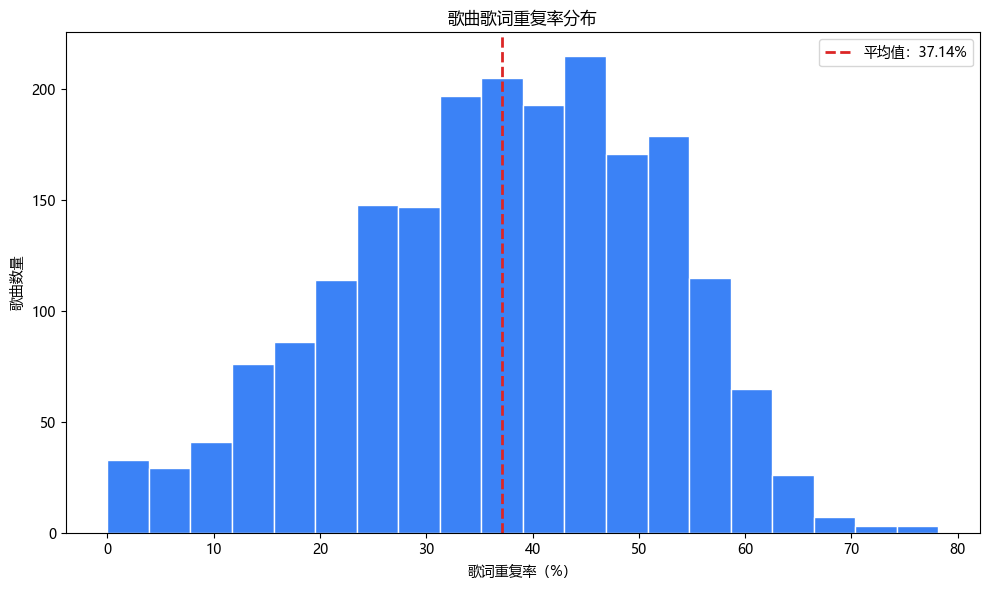

In [ ]:
repetition_rates = np.array([
    record["repetition_rate"] * 100 for record in records
])

mean_repetition = float(np.mean(repetition_rates))
median_repetition = float(np.median(repetition_rates))
below_20 = int(np.sum(repetition_rates < 20))
between_20_60 = int(np.sum((repetition_rates >= 20) & (repetition_rates <= 60)))
above_60 = int(np.sum(repetition_rates > 60))

print(f"平均重复率：{mean_repetition:.2f}%")
print(f"重复率中位数：{median_repetition:.2f}%")
print(f"低于20%：{below_20}首，占比{below_20 / len(records):.2%}")
print(f"20%至60%：{between_20_60}首，占比{between_20_60 / len(records):.2%}")
print(f"高于60%：{above_60}首，占比{above_60 / len(records):.2%}")

plt.figure(figsize=(10, 6))
plt.hist(repetition_rates, bins=20, color="#3B82F6", edgecolor="white")
plt.axvline(mean_repetition, color="#DC2626", linestyle="--", linewidth=2,
            label=f"平均值：{mean_repetition:.2f}%")
plt.title("歌曲歌词重复率分布")
plt.xlabel("歌词重复率（%）")
plt.ylabel("歌曲数量")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lyric_repetition_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

参与评论分析的歌曲数：2046
皮尔逊相关系数：-0.0206


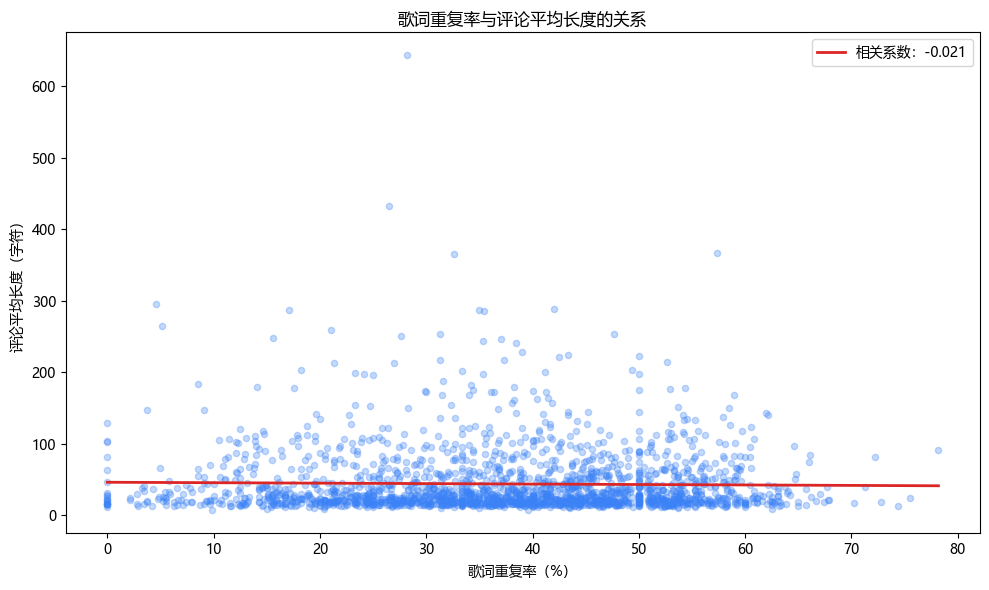

In [ ]:
comment_records = [record for record in records if record["average_comment_length"] > 0]
x_repetition = np.array([
    record["repetition_rate"] * 100 for record in comment_records
])
y_comment_length = np.array([
    record["average_comment_length"] for record in comment_records
])

correlation = float(np.corrcoef(x_repetition, y_comment_length)[0, 1])
trend_line = np.poly1d(np.polyfit(x_repetition, y_comment_length, 1))
x_line = np.linspace(x_repetition.min(), x_repetition.max(), 100)

print(f"参与评论分析的歌曲数：{len(comment_records)}")
print(f"皮尔逊相关系数：{correlation:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(x_repetition, y_comment_length, alpha=0.30, s=20, color="#3B82F6")
plt.plot(x_line, trend_line(x_line), color="#DC2626", linewidth=2,
         label=f"相关系数：{correlation:.3f}")
plt.title("歌词重复率与评论平均长度的关系")
plt.xlabel("歌词重复率（%）")
plt.ylabel("评论平均长度（字符）")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "repetition_comment_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

**结论一：** 2053首有效歌曲的平均歌词重复率为38.48%，其中81.25%的歌曲位于20%至60%，说明歌词重复是较普遍的结构特征，但极高重复率歌曲只占少数。歌词重复率与评论平均长度的相关系数约为-0.016，两者几乎没有线性关系。评论长度可能更多受到个人经历、情感共鸣和少量长评论等因素影响。


## 五、结果二：同歌手歌曲的歌词用词更相似

为避免副歌重复直接影响用词风格分析，分词前先去除完全重复的歌词行。合唱歌曲不参与本项分析。同歌手组使用全部组合，不同歌手组使用固定随机种子抽取等量组合作为对照。  
  
代码逻辑如下：
```text
  定义分词函数，设计过程中选择用字典转化保障了歌词的有序性，又能减少重复歌词对词频统计的影响。随后分词选取出有效词汇。  

  接下来筛选有效的歌曲“similarity_songs”并生成对应的文本集“documents”（元素为以空格间隔连接的字符串）。

  “vectorizer”使用空格分隔，不调用原有分词模式，无需预处理（已通过lower处理）。同时要求被选中的词汇至少在两片文本中出现，且不能在多余百分之八十的文本中出现（略去生僻、无意义的词汇）。计算得到tf-idf矩阵。形状为（文档数，词表大小）。  

  计算任意两首歌之间的余弦相似度，并存储为相似度矩阵。  

  求所有二元组的列表“same_pairs”，满足所有二元组里的两个下标对应的歌曲为同一个歌手演唱。将每个歌手的歌曲形成列表，歌手为键，列表为值，得到一张字典。根据字典，调用“combinations”方法，从“indices”中取出所有下标组合,不考虑顺序、不重复。依据下标可以取得分数。  

  求所有二元组的列表“different_pairs”（代码中并没有写出），满足所有二元组里的两个下标对应的歌曲为不同歌手演唱，且应确保数量与“same_pairs”一致。于是使用while循环，随机抽取两个下标，判断为非同一歌手演唱，则计算分数并加入列表。

  最后分别计算两组相似度的平均值和中位数，并绘制箱线图进行比较。箱线图可以同时展示两组相似度的集中趋势和分布差异，从而判断同一歌手的歌词在用词层面是否表现出更强的一致性。
```


In [ ]:
STOP_WORDS = {
    "的", "了", "着", "是", "在", "和", "与", "也", "都", "就", "又",
    "而", "但", "却", "还", "很", "我", "你", "他", "她", "它", "我们",
    "你们", "他们", "这", "那", "一个", "一种", "什么", "怎么", "没有",
    "到", "最", "再", "会", "有", "里", "已", "是否", "还是", "现在",
    "原来", "一次", "一遍", "自己",
}


def tokenize_lyrics(cleaned_lyrics):
    unique_lines = list(dict.fromkeys(cleaned_lyrics))
    words = jieba.lcut(" ".join(unique_lines).lower())
    valid_words = []

    for word in words:
        word = word.strip()
        if not word or word in STOP_WORDS:
            continue
        if re.fullmatch(r"[一-鿿]+", word):
            valid_words.append(word)
        elif re.fullmatch(r"[a-z]+", word) and len(word) >= 2:
            valid_words.append(word)

    return valid_words


similarity_songs = []
documents = []

for song in songs:
    singer_ids = song.get("song_singer_ids", [])
    if len(singer_ids) != 1:
        continue

    cleaned_lyrics = clean_lyrics(song.get("song_lyrics", []))
    if len(cleaned_lyrics) < 5:
        continue

    words = tokenize_lyrics(cleaned_lyrics)
    if len(words) < 10:
        continue

    similarity_songs.append({
        "song_title": song.get("song_title", "未知歌曲"),
        "song_singer": song.get("song_singer", "未知歌手"),
        "singer_id": singer_ids[0],
    })
    documents.append(" ".join(words))

vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    min_df=2,
    max_df=0.8,
    sublinear_tf=True,
)
tfidf_matrix = vectorizer.fit_transform(documents)
similarity_matrix = cosine_similarity(tfidf_matrix)

singer_indices = defaultdict(list)
for index, song in enumerate(similarity_songs):
    singer_indices[song["singer_id"]].append(index)

same_pairs = []
for indices in singer_indices.values():
    if len(indices) >= 2:
        same_pairs.extend(combinations(indices, 2))

same_scores = [similarity_matrix[i, j] for i, j in same_pairs]

random_generator = random.Random(42)
different_scores = []
while len(different_scores) < len(same_scores):
    i, j = random_generator.sample(range(len(similarity_songs)), 2)
    if similarity_songs[i]["singer_id"] == similarity_songs[j]["singer_id"]:
        continue
    different_scores.append(similarity_matrix[i, j])

print(f"参与分析的独唱歌曲数：{len(similarity_songs)}")
print(f"TF-IDF词汇数量：{len(vectorizer.get_feature_names_out())}")
print(f"每组歌曲组合数：{len(same_scores)}")
print(f"同歌手平均相似度：{np.mean(same_scores):.4f}")
print(f"不同歌手平均相似度：{np.mean(different_scores):.4f}")
print(f"同歌手相似度中位数：{np.median(same_scores):.4f}")
print(f"不同歌手相似度中位数：{np.median(different_scores):.4f}")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\13811\AppData\Local\Temp\jieba.cache
Loading model cost 0.226 seconds.
Prefix dict has been built successfully.


参与分析的独唱歌曲数：1898
TF-IDF词汇数量：14402
每组歌曲组合数：6955
同歌手平均相似度：0.0987
不同歌手平均相似度：0.0222
同歌手相似度中位数：0.0577
不同歌手相似度中位数：0.0151


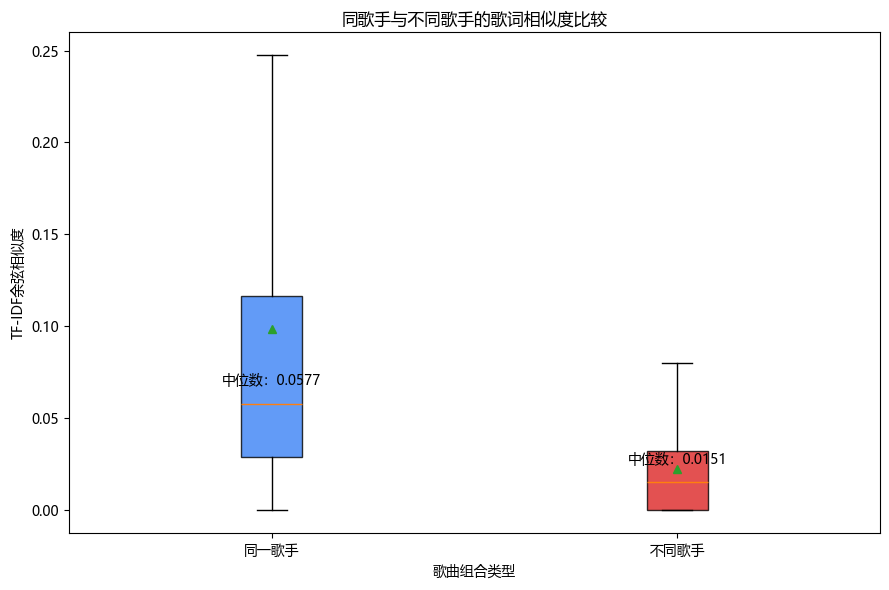

In [9]:
plt.figure(figsize=(9, 6))
boxplot = plt.boxplot(
    [same_scores, different_scores],
    tick_labels=["同一歌手", "不同歌手"],
    patch_artist=True,
    showmeans=True,
    showfliers=False,
)

for box, color in zip(boxplot["boxes"], ["#3B82F6", "#DC2626"]):
    box.set_facecolor(color)
    box.set_alpha(0.8)

plt.title("同歌手与不同歌手的歌词相似度比较")
plt.xlabel("歌曲组合类型")
plt.ylabel("TF-IDF余弦相似度")
plt.text(1, np.median(same_scores) + 0.01,
         f"中位数：{np.median(same_scores):.4f}", ha="center")
plt.text(2, np.median(different_scores) + 0.01,
         f"中位数：{np.median(different_scores):.4f}", ha="center")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "same_vs_different_singer_similarity.png", dpi=200,
            bbox_inches="tight")
plt.show()

**结论二：** 同歌手歌曲的平均歌词相似度为0.0876，是不同歌手0.0238的约3.68倍；两组中位数分别为0.0468和0.0167。同一歌手的歌曲可能具有较稳定的用词和主题风格，但这种差异也可能受到作词人、曲风和发行时期影响。


## 六、结果三：不同出生年代歌手的歌词重复率存在差异

下面根据歌手生日提取出生年份，以十年为一组。为保证可读性，只展示包含不少于30首歌曲的年代。  
代码逻辑如下：
```text
  首先从歌手数据“singers”中提取出生年份。由于歌手生日字段中可能包含完整日期，也可能存在缺失或格式不统一的情况，因此这里使用正则表达式匹配“19xx”或“20xx”形式的年份；如果无法匹配，则跳过该歌手。随后将有效的“singer_id”和出生年份对应起来，构建“singer_birth_years”字典，方便后续通过歌曲中的歌手ID查找出生年代。

  接下来遍历歌曲数据“songs”。为了避免合唱歌曲影响年代归属，本部分仍然只保留具有唯一歌手ID的独唱歌曲；如果该歌手ID无法在“singer_birth_years”中找到对应出生年份，则跳过。然后继续沿用前面已经定义好的“clean_lyrics”函数清洗歌词，并排除有效歌词行数少于5行的歌曲。对于符合条件的歌曲，调用“calculate_lyric_metrics”计算歌词重复率，再根据歌手出生年份计算其所属年代，例如1992年归入1990年代。

  得到每首歌曲对应的出生年代和重复率后，将重复率按年代存入“decade_rates”字典。为了减少样本过少带来的偶然性，本次分析只保留样本歌曲数不少于30首的年代。随后分别计算每个年代的歌曲数量、平均重复率和重复率中位数，并整理为“decade_summaries”列表，便于打印结果和绘图。

  最后根据“decade_summaries”绘制分组柱状图。横轴表示歌手出生年代，纵轴表示歌词重复率；蓝色柱子展示平均重复率，红色柱子展示中位数，并在每组柱子上方标注样本量“n”。通过平均值和中位数的对比，可以观察不同出生年代歌手歌曲重复率的大致变化趋势，同时也能避免只依赖单一统计指标造成误读。
  ```

In [10]:
def extract_birth_year(singer):
    birthday = singer.get("生日", "")
    match = re.search(r"(19\d{2}|20\d{2})", str(birthday))
    return int(match.group(1)) if match else None


singer_birth_years = {}
for singer in singers:
    birth_year = extract_birth_year(singer)
    if birth_year is not None and singer.get("singer_id"):
        singer_birth_years[singer["singer_id"]] = birth_year

decade_rates = defaultdict(list)
for song in songs:
    singer_ids = song.get("song_singer_ids", [])
    if len(singer_ids) != 1 or singer_ids[0] not in singer_birth_years:
        continue

    cleaned = clean_lyrics(song.get("song_lyrics", []))
    if len(cleaned) < 5:
        continue

    _, _, repetition_rate = calculate_lyric_metrics(cleaned)
    decade = singer_birth_years[singer_ids[0]] // 10 * 10
    decade_rates[decade].append(repetition_rate)

decade_summaries = []
for decade, rates in sorted(decade_rates.items()):
    if len(rates) < 30:
        continue
    decade_summaries.append({
        "decade": decade,
        "song_count": len(rates),
        "mean_rate": float(np.mean(rates)),
        "median_rate": float(np.median(rates)),
    })

print("出生年代  歌曲数  平均重复率  中位数")
for summary in decade_summaries:
    print(
        f"{summary['decade']}年代  {summary['song_count']:>4}首  "
        f"{summary['mean_rate']:.2%}  {summary['median_rate']:.2%}"
    )

出生年代  歌曲数  平均重复率  中位数
1950年代    47首  42.36%  46.00%
1960年代   189首  43.58%  46.81%
1970年代   262首  38.53%  40.45%
1980年代   540首  36.18%  36.36%
1990年代   353首  33.69%  35.00%
2000年代    50首  31.77%  35.52%


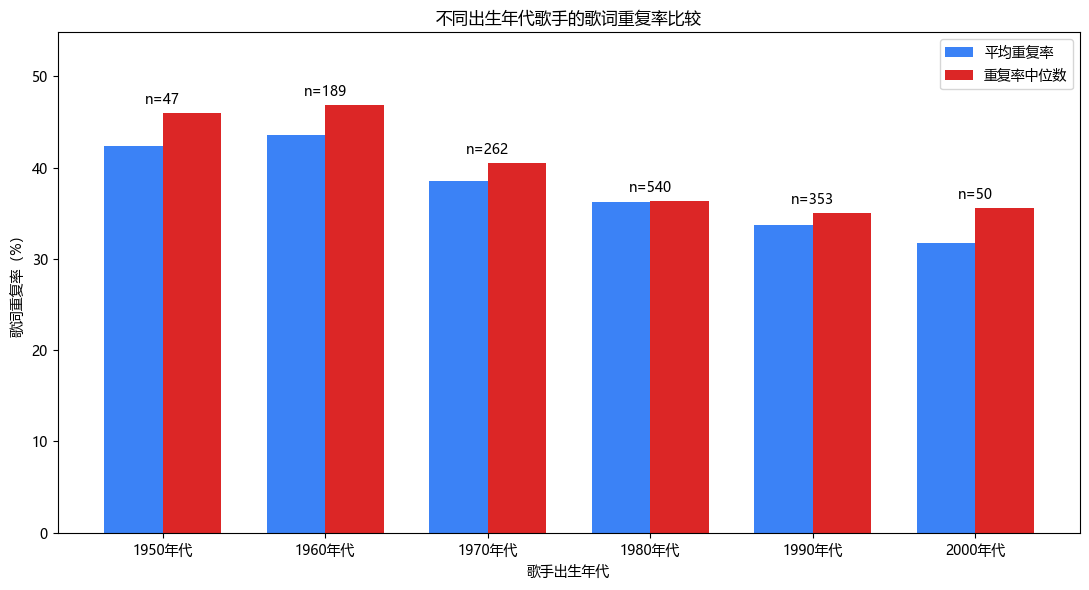

In [11]:
decade_labels = [f"{item['decade']}年代" for item in decade_summaries]
mean_rates = [item["mean_rate"] * 100 for item in decade_summaries]
median_rates = [item["median_rate"] * 100 for item in decade_summaries]
song_counts = [item["song_count"] for item in decade_summaries]

x_positions = np.arange(len(decade_labels))
bar_width = 0.36

plt.figure(figsize=(11, 6))
plt.bar(x_positions - bar_width / 2, mean_rates, width=bar_width,
        label="平均重复率", color="#3B82F6")
plt.bar(x_positions + bar_width / 2, median_rates, width=bar_width,
        label="重复率中位数", color="#DC2626")
plt.xticks(x_positions, decade_labels)
plt.xlabel("歌手出生年代")
plt.ylabel("歌词重复率（%）")
plt.title("不同出生年代歌手的歌词重复率比较")
plt.legend()

for index, count in enumerate(song_counts):
    plt.text(index, max(mean_rates[index], median_rates[index]) + 1,
             f"n={count}", ha="center")

plt.ylim(0, max(max(mean_rates), max(median_rates)) + 8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "birth_decade_repetition.png", dpi=200,
            bbox_inches="tight")
plt.show()

**结论三：** 1950年代和1960年代出生歌手的样本歌曲平均重复率均超过44%，从1960年代以后各年代平均值连续下降，到2000年代降至32.71%。这说明本次样本中较年轻代际歌手的歌曲使用完全相同歌词行的比例整体更低，但不能据此直接推断整个音乐市场随时代变化的规律。


## 七、总结与局限性

### 主要发现

1. 歌词重复是样本歌曲的常见结构，但不能有效解释评论篇幅。
2. 同歌手歌曲在词语层面表现出更高的一致性。
3. 从1960年代至2000年代出生歌手的样本中，歌词平均重复率呈下降趋势。

### 局限性

- 规则清洗可能残留少量制作信息，也可能无法覆盖特殊歌词格式。
- 每首歌曲只采集约3条评论，评论结论的代表性有限。
- TF-IDF衡量的是词语相似性，而不是完整语义相似性。
- 以出生年代分析，缺少歌曲发行年份，且各年代样本量不均衡。

后续可补充歌曲发行年份、情感语义分析和多次随机抽样，对当前结果做进一步验证。
